# Monte Carlo Simulation

## For a single stock:

In [17]:
# Configurations

stock = "AAPL"
start = "2018-01-01"
end = "2024-01-01"

/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_44449/2541245205.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


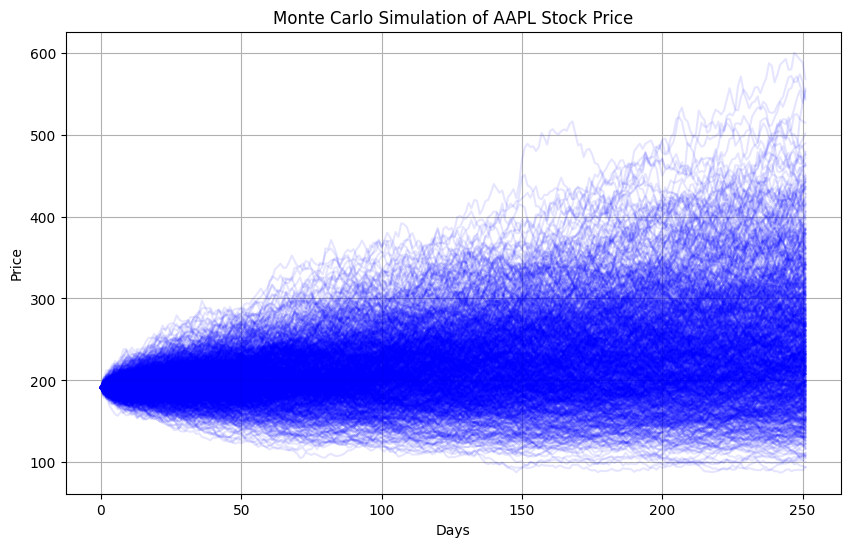

In [18]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def monte_carlo_simulation(ticker= stock, start= start, end= end,
                           num_simulations= 1000, num_days=252):
    # 1. Download historical data
    data = yf.download(ticker, start=start, end=end)
    prices = data['Close']
    
    # 2. Calculate daily log returns
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 3. Calculate mean and standard deviation
    mu = log_returns.mean().item()
    sigma = log_returns.std().item()

    # 4. Initialize simulation
    S0 = prices.iloc[-1]  # Last observed price
    simulations = np.zeros((num_days, num_simulations))
    simulations[0] = S0

    # 5. Run simulations
    for t in range(1, num_days):
        z = np.random.standard_normal(num_simulations)  # Random draws
        simulations[t] = simulations[t - 1] * np.exp((mu - 0.5 * sigma**2) + sigma * z)

    # 6. Plot
    plt.figure(figsize=(10, 6))
    plt.plot(simulations, alpha=0.1, color='blue')
    plt.title(f"Monte Carlo Simulation of {ticker} Stock Price")
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()

    return simulations

simulations = monte_carlo_simulation(ticker=stock, start=start, end=end)


In [19]:
percentile = 5 # For VAR (value at risk) calculation

ending_prices = simulations[-1]
initial_price = simulations[0][0]
returns = (ending_prices - initial_price) / initial_price
VaR_5 = np.percentile(returns, percentile) 

print(f"{percentile}% Value at Risk (1-year): {VaR_5:.2%}")

5% Value at Risk (1-year): -27.33%


## For a portfolio:

In [30]:
tickers = ["TSLA", "PLTR", "AMD", "TEM", "HOOD", "COIN", "MSFT", "KO", "PEP", "INTC"]
weights = np.array([0.1]*10)  # Equal-weight portfolio
start = "2018-01-01"
end = "2025-07-25"
percentile = 5

/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_44449/243937564.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end)["Close"]
[*********************100%***********************]  10 of 10 completed


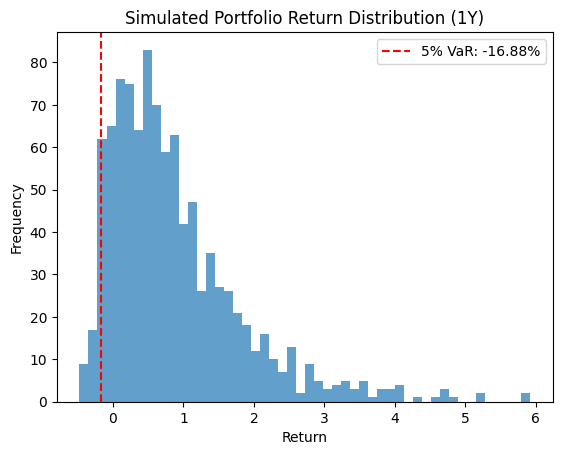

5% Value at Risk (1-year): -16.88%


In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def monte_carlo_portfolio(tickers, weights, start, end, num_simulations=1000, num_days=252):
    # Download historical adjusted close prices
    data = yf.download(tickers, start=start, end=end)["Close"]
    log_returns = np.log(data / data.shift(1)).dropna()
    
    # Compute annualized mean and covariance of log returns
    mu = log_returns.mean().values  # shape (n_assets,)
    cov = log_returns.cov().values  # shape (n_assets, n_assets)

    # Cholesky decomposition for correlated paths
    L = np.linalg.cholesky(cov)

    portfolio_returns = []

    for i in range(num_simulations):
        prices = np.ones((num_days + 1, len(tickers)))  # relative to 1
        for t in range(1, num_days + 1):
            z = np.random.normal(size=len(tickers))  # uncorrelated standard normals
            correlated = L @ z  # apply correlation
            drift = mu - 0.5 * np.diag(cov)
            prices[t] = prices[t - 1] * np.exp(drift + correlated)
        
        # Compute portfolio value path
        weighted_prices = prices @ weights
        total_return = (weighted_prices[-1] - weighted_prices[0]) / weighted_prices[0]
        portfolio_returns.append(total_return)

    # Compute Value at Risk (VaR)
    VaR_5 = np.percentile(portfolio_returns, percentile)

    # Plot distribution
    plt.hist(portfolio_returns, bins=50, alpha=0.7)
    plt.axvline(VaR_5, color='red', linestyle='--', label=f'{percentile}% VaR: {VaR_5:.2%}')
    plt.title("Simulated Portfolio Return Distribution (1Y)")
    plt.xlabel("Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    print(f"{percentile}% Value at Risk (1-year): {VaR_5:.2%}")
    return portfolio_returns

portfolio_returns = monte_carlo_portfolio(tickers, weights, start, end)